In [150]:
from matplotlib import pyplot as plt
import numpy as np
from astropy.io import fits
import healpy as hp
from healpy.newvisufunc import projview, newprojplot
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.ndimage import map_coordinates

In [151]:
import matplotlib.colors as mcolors
original_cmap = plt.get_cmap('Set1')

colors = original_cmap(np.arange(1,6,1))
Set11 = mcolors.ListedColormap(colors)

In [152]:
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_Npeaks_8sigma.hpx.fits' 
eightsigmapeaksdat = fits.getdata(fn)
eightsigmapeakdshdr = fits.getheader(fn)
fn1 = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_Npeaks_8sigma.car.fits' 
eightsigmapeakscardat = fits.getdata(fn1)
eightsigmapeakscarhdr = fits.getheader(fn1)

(70.0, 90.0)

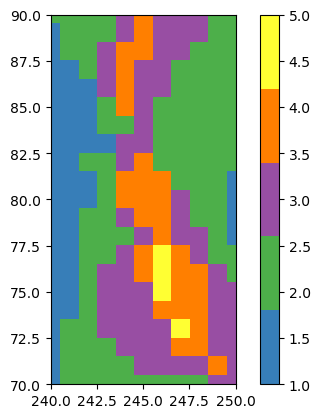

In [153]:
fig, ax = plt.subplots(1,1) 
im = ax.imshow(eightsigmapeakscardat, 
               cmap = Set11, vmin =1, vmax = 5,
               origin = 'lower'
              )
plt.colorbar(im)
ax.set_xlim(240,250)
ax.set_ylim(70,90)

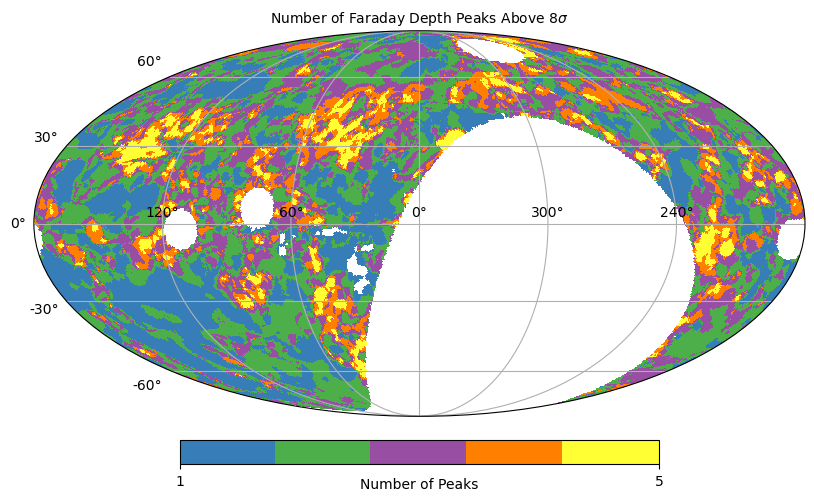

In [154]:
projview(
    eightsigmapeaksdat,
    projection_type = 'mollweide', 
    graticule = True, 
    graticule_labels=True, 
    # xlabel="Longitude", 
    # ylabel="Latitude", 
    cb_orientation = "horizontal",
    cmap = Set11,
    min = 1, 
    max = 5,
    unit = r'Number of Peaks',
    title = r'Number of Faraday Depth Peaks Above 8$\sigma$', 
    fontsize={
    "title":10,
    "xtick_label":10,
    "ytick_label":10, 
    "cbar_label":10
    }
    )

In [6]:
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_Npeaks_8sigma.car.fits'
Npeakscardat = fits.getdata(fn)
Npeakscarhdr = fits.getheader(fn)

In [7]:
#loading dirty Faraday Depth Cube for spectra
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_tot_dirty_Kgal.car.fits'
FDdirtydat = fits.getdata(fn)
FDdirtyhdr = fits.getheader(fn)

In [8]:
#loading clean Faraday Depth Cube for spectra from DRAGONS
fn = '~/Research/DRAGONS/DRAGONS_faraday_depth_cubes/faraday_synthesis/dragons_FDF_clean_tot_Kgal.car.fits'
FDcleandat = fits.getdata(fn) 
FDcleanhdr = fits.getheader(fn)

In [9]:
wcs = WCS(FDcleanhdr)
wcs

WCS Keywords

Number of WCS axes: 3
CTYPE : 'GLON-CAR' 'GLAT-CAR' 'FDEP' 
CRVAL : np.float64(0.0) np.float64(0.0) np.float64(0.0) 
CRPIX : np.float64(360.5) np.float64(180.5) np.float64(401.0) 
PC1_1 PC1_2 PC1_3  : np.float64(1.0) np.float64(0.0) np.float64(0.0) 
PC2_1 PC2_2 PC2_3  : np.float64(0.0) np.float64(1.0) np.float64(0.0) 
PC3_1 PC3_2 PC3_3  : np.float64(0.0) np.float64(0.0) np.float64(1.0) 
CDELT : np.float64(-0.5) np.float64(0.5) np.float64(0.5) 
NAXIS : 720  360  801

In [10]:
FDcleanhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                  720                                                  
NAXIS2  =                  360                                                  
NAXIS3  =                  801                                                  
COORDSYS= 'Galactic '          / Ecliptic, Galactic or Celestial (equatorial)   
CRPIX2  =                180.5                                                  
CDELT2  =                  0.5                                                  
CUNIT2  = 'deg     '                                                            
BUNIT   = 'K/RMSF  '                                                            
CTYPE2  = 'GLAT-CAR'                                                            
CRVAL2  =                   

In [11]:
Npeakscarhdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  720                                                  
NAXIS2  =                  360                                                  
COORDSYS= 'galactic'           / Ecliptic, Galactic or Celestial (equatorial)   
CRPIX2  =                180.5                                                  
CDELT2  =                  0.5                                                  
CUNIT2  = 'deg     '                                                            
BUNIT   = 'NUMBER  '                                                            
CTYPE2  = 'GLAT-CAR'                                                            
CRVAL2  =                    0                                                  
CTYPE1  = 'GLON-CAR'        

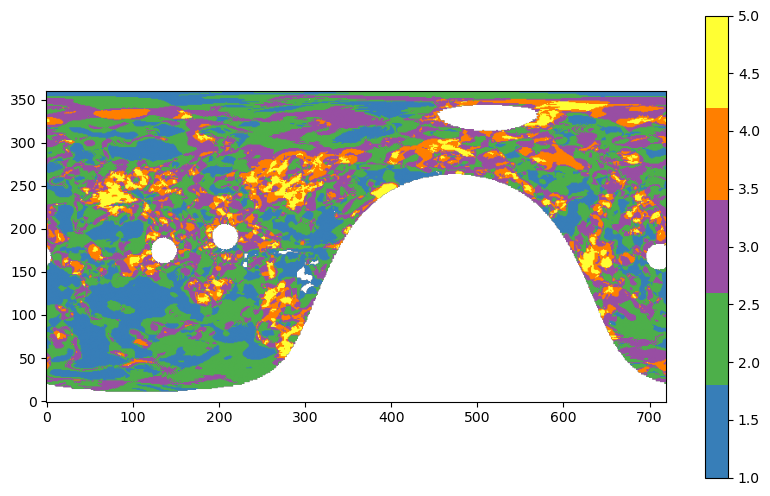

In [12]:
figsize = (10, 6)
fig, ax = plt.subplots(1,1, figsize = figsize)#, subplot_kw={'projection'})#: wcs.celestial})
im0 = ax.imshow(Npeakscardat, origin='lower', cmap = Set11, vmin=1, vmax=5)

plt.colorbar(im0)
plt.show()

In [13]:
mask = (5 < Npeakscardat) & (Npeakscardat < 7)
yIndices, xIndices = np.where(mask)

sixCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(sixCompPixCoord), sixCompPixCoord[:5]) 

1250 [[276  56]
 [277  56]
 [278  56]
 [279  56]
 [280  56]]


In [14]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(sixCompPixCoord)))
compSixNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(sixCompPixCoord[currentIndex])]
    queue = [sixCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = sixCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(sixCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(sixCompPixCoord[actualIdx])
        
        compSixNewLoS.append(currentRegion)

minimumPixArea = 59 
compSixResolvedRegions = [r for r in compSixNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compSixResolvedRegions)}, distinct lines of sight: {len(compSixNewLoS)}")

Number of regions: 737, distinct lines of sight: 1217


In [15]:
wcs = WCS(Npeakscarhdr)
compSixLoSGalCoords = []
for region in compSixNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compSixLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compSixLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compSixLoSGalCoords[0]},\n{compSixLoSGalCoords[17]}")

Number of LoS: 1217
Example LoS galactic coords 
[[ 41.75 -61.75]
 [ 41.25 -58.25]
 [ 41.75 -58.25]
 [ 40.25 -58.75]
 [ 40.75 -58.75]
 [ 39.75 -59.25]
 [ 40.25 -59.25]
 [ 40.75 -59.25]
 [ 41.25 -59.25]
 [ 43.75 -59.25]
 [ 44.25 -59.25]
 [ 39.25 -59.75]
 [ 39.75 -59.75]
 [ 40.25 -59.75]
 [ 40.75 -59.75]
 [ 42.75 -59.75]
 [ 43.25 -59.75]
 [ 38.75 -60.25]
 [ 39.25 -60.25]
 [ 39.75 -60.25]
 [ 43.25 -60.25]
 [ 39.25 -61.25]
 [ 39.75 -61.25]
 [ 40.25 -61.25]
 [ 40.75 -61.25]
 [ 41.25 -61.25]
 [ 41.75 -61.25]
 [ 39.25 -61.75]
 [ 39.75 -61.75]
 [ 40.25 -61.75]
 [ 40.75 -61.75]
 [ 41.25 -61.75]
 [ 41.25 -54.75]
 [ 41.25 -55.25]
 [ 40.75 -55.75]
 [ 41.25 -55.75]
 [ 39.75 -56.25]
 [ 40.25 -56.25]
 [ 40.75 -56.25]
 [ 41.25 -56.25]
 [ 39.25 -56.75]
 [ 39.75 -56.75]
 [ 41.25 -56.75]
 [ 38.75 -57.25]
 [ 39.25 -57.25]
 [ 39.75 -57.25]
 [ 40.25 -57.25]
 [ 40.75 -57.25]
 [ 38.75 -57.75]
 [ 39.25 -57.75]
 [ 39.75 -57.75]
 [ 40.25 -57.75]
 [ 40.75 -57.75]
 [ 41.25 -57.75]
 [ 41.75 -57.75]
 [ 39.25 -58.25]

In [16]:
mask = (6 < Npeakscardat) & (Npeakscardat < 8)

yIndices, xIndices = np.where(mask)

sevenCompPixCoord = np.column_stack((xIndices, yIndices)) 

print(len(sevenCompPixCoord), sevenCompPixCoord[:5]) 

242 [[277  65]
 [278  66]
 [279  66]
 [641 103]
 [642 103]]


In [17]:
wcs = WCS(Npeakscarhdr, naxis =2)

beamLimit = 7.2 #pixels 
group = list(range(len(sevenCompPixCoord)))
compSevenNewLoS = []
while group: 
    currentIndex = group.pop(0)
    currentRegion = [tuple(sevenCompPixCoord[currentIndex])]
    queue = [sevenCompPixCoord[currentIndex]] 

    while queue: 
        point = queue.pop(0)

        if not group: 
            break 

        groupCoords = sevenCompPixCoord[group] 
        distances = np.linalg.norm(groupCoords - point, axis=1)

        closeIndices = np.where(distances <= beamLimit)[0]

        for idx in sorted(closeIndices, reverse=True):
            actualIdx = group.pop(idx)
            pixel = tuple(sevenCompPixCoord[actualIdx])
            currentRegion.append(pixel)
            queue.append(sevenCompPixCoord[actualIdx])
        
        compSevenNewLoS.append(currentRegion)

minimumPixArea = 59 
compSevenResolvedRegions = [r for r in compSevenNewLoS if len(r) >= minimumPixArea]

print(f"Number of regions: {len(compSevenResolvedRegions)}, distinct lines of sight: {len(compSevenNewLoS)}")

Number of regions: 68, distinct lines of sight: 241


In [18]:
wcs = WCS(Npeakscarhdr)
compSevenLoSGalCoords = []
for region in compSevenNewLoS:
    regionArray = np.array(region)
    skyCoords = wcs.pixel_to_world(regionArray[:, 0], regionArray[:, 1])
    galCoords = skyCoords.galactic
    galArray = np.column_stack((galCoords.l.deg, galCoords.b.deg))
    compSevenLoSGalCoords.append(galArray)

print(f"Number of LoS: {len(compSevenLoSGalCoords)}")
print(f"Example LoS galactic coords \n{compSevenLoSGalCoords[0]},\n{compSevenLoSGalCoords[17]}")

Number of LoS: 241
Example LoS galactic coords 
[[ 41.25 -57.25]
 [ 40.25 -56.75]
 [ 40.75 -56.75]],
[[228.25 -12.75]
 [226.75  -9.75]
 [227.25  -9.75]
 [227.75  -9.75]
 [225.75 -10.25]
 [226.25 -10.25]
 [227.25 -10.25]
 [227.75 -10.75]
 [227.25 -11.25]
 [227.75 -11.25]
 [228.25 -11.25]
 [227.25 -11.75]
 [227.75 -11.75]
 [228.25 -11.75]
 [227.25 -12.25]
 [227.75 -12.25]
 [228.25 -12.25]
 [228.75 -12.25]
 [226.75 -12.75]
 [227.25 -12.75]
 [227.75 -12.75]
 [224.25  -7.75]
 [223.75  -8.25]
 [224.25  -8.25]
 [223.75  -4.25]
 [222.75  -4.75]
 [223.25  -7.25]
 [222.75  -3.75]
 [223.25  -3.75]
 [223.75  -3.75]
 [222.75  -4.25]
 [223.25  -4.25]]


In [19]:
wcsEngine = WCS(Npeakscarhdr)

uniqueComplexities, groupInverseIndices = np.unique(Npeakscardat, return_inverse=True)

for groupIndex, complexityValue in enumerate(uniqueComplexities):

    currentGroupMask = (groupInverseIndices == groupIndex)

    pixelCoordinates = np.where(currentGroupMask)

    if len(pixelCoordinates[0]) == 0: 
        continue 

    worldCoordinates = wcsEngine.pixel_to_world(*pixelCoordinates[::-1])

    skyPositions = SkyCoord(worldCoordinates) 
    galacticCoordinates = skyPositions.galactic

    galacticLongitude = galacticCoordinates.l.degree
    galacticLatitude = galacticCoordinates.b.degree

    print(f"Complexity Group: {complexityValue} | Found {len(galacticLongitude)} pixel.") 
    

Complexity Group: 1.0 | Found 37695 pixel.
Complexity Group: 2.0 | Found 60185 pixel.
Complexity Group: 3.0 | Found 45373 pixel.
Complexity Group: 4.0 | Found 18940 pixel.
Complexity Group: 5.0 | Found 5602 pixel.
Complexity Group: 6.0 | Found 1250 pixel.
Complexity Group: 7.0 | Found 242 pixel.
Complexity Group: 8.0 | Found 19 pixel.
Complexity Group: nan | Found 89894 pixel.


In [20]:
fn = '/home/justin/Research/WHAM/wham-ss-DR1-v161116-170912-grid.fits'
whamdat = fits.getdata(fn)
whamhdr = fits.getheader(fn)

whamhdr

In [21]:
whamhdr

 [astropy.io.fits.verify]


SIMPLE  =                    T /  Written by IDL:  Tue Sep 12 13:28:51 2017     
BITPIX  =                  -32 / Real*4 (floating point)                        
NAXIS   =                    3 /                                                
NAXIS1  =                 1440 /                                                
NAXIS2  =                  720 /                                                
NAXIS3  =                  162 /                                                
EXTEND  =                    T / Extensions may be present                      
DATE    = '2017-09-12'         /                                                
TAG     = 'DR1     '           / General release tag                            
VERSION = '161116  '           / Generated from wham-ss-161116.sav              
OBJECT  = 'WHAM Sky Survey - Release DR1 (161116)' /                            
RESTWAV =          6.56300E-07 / Rest wavelength of H-alpha [m]                 
BSCALE  =              1.000

In [22]:
from astropy.wcs import WCS
from astropy.wcs.utils import skycoord_to_pixel
from astropy.coordinates import SkyCoord
import numpy as np

wcsEngineFaraday = WCS(Npeakscarhdr)
wcsWham = WCS(whamhdr)

wcsWhamCelestial = wcsWham.celestial

uniqueComplexities, groupInverseIndices = np.unique(Npeakscardat, return_inverse=True)

analysisLibraryHalpha = {}

for groupIndex, complexityValue in enumerate(uniqueComplexities):
    
    # Isolate matching pixels for the current group
    currentGroupMask = (groupInverseIndices == groupIndex)
    faradayPixelCoords = np.where(currentGroupMask)
    
    if len(faradayPixelCoords[0]) == 0:
        continue
        
    # Extract the raw data values and flat pixel index tracks for this group
    currentFaradayValues = Npeakscardat[currentGroupMask]
    currentFlatPixels = np.flatnonzero(currentGroupMask)
    
    # --- Step A: Generate Galactic Coordinates (l, b) ---
    # Unpack pixel coordinates in reverse order for FITS convention
    worldCoordinates = wcsEngineFaraday.pixel_to_world(*faradayPixelCoords[::-1])
    skyPositions = SkyCoord(worldCoordinates)
    galacticCoordinates = skyPositions.galactic
    
    # Pack the spatial positions into a clean 2D Galactic SkyCoord object
    spatialPositions2D = SkyCoord(
        l=galacticCoordinates.l, 
        b=galacticCoordinates.b, 
        frame='galactic'
    )
    
    # --- Step B: Extract 2D Spatial Pixels ---
    # skycoord_to_pixel guarantees it returns two separate, clean 1D arrays: (x, y)
    xFloats, yFloats = skycoord_to_pixel(spatialPositions2D, wcsWhamCelestial, origin=0)
    
    xIndices = np.round(xFloats).astype(int)
    yIndices = np.round(yFloats).astype(int)
    
    # --- Step C: Boundary Guard Against 2D WHAM ---
    yBoundSize = whamdat.shape[1]
    xBoundSize = whamdat.shape[2]
    
    inBounds = (
        (xIndices >= 0) & (xIndices < xBoundSize) &
        (yIndices >= 0) & (yIndices < yBoundSize)
    )
    
    if not np.any(inBounds):
        continue
        
    # --- Step D: Data Extraction and Array Masking ---
    # Squeeze out valid horizontal/vertical spatial layout vectors
    validX = xIndices[inBounds]
    validY = yIndices[inBounds]
    
    # Extract intensity values from the target slice 
    # Change the first index '0' to whichever velocity channel index holds your map data
    matchedWhamIntensities = whamdat[0, validY, validX]
    
    # --- Step E: Save Final Subsets to Master Library ---
    analysisLibraryHalpha[complexityValue] = {
        "faradayValues": currentFaradayValues[inBounds],
        "hAlphaIntensities": matchedWhamIntensities,
        "galacticLongitude": galacticCoordinates.l.degree[inBounds],
        "galacticLatitude": galacticCoordinates.b.degree[inBounds],
        "flatPixelNumbers": currentFlatPixels[inBounds]
    }

print(f"Pipeline executed successfully! Populated {len(analysisLibraryHalpha)} groups into 'analysisLibraryHalpha'.")


Pipeline executed successfully! Populated 9 groups into 'analysisLibraryHalpha'.


In [23]:
from scipy.stats import pearsonr, spearmanr
allFaradayValues = np.concatenate([
    groupData["faradayValues"] for groupData in analysisLibraryHalpha.values() if len(groupData["faradayValues"])>0
])
allHAlphaIntensities = np.concatenate([
    groupData["hAlphaIntensities"] for groupData in analysisLibraryHalpha.values() if len(groupData["hAlphaIntensities"])>0
])
print("---Data Population Health Check ---")
print(f"Total Combined Matching Pixels: {len(allFaradayValues)}")

validCalculationMask = (
    ~np.isnan(allFaradayValues) & ~np.isinf(allFaradayValues) &
    ~np.isnan(allHAlphaIntensities) & ~np.isinf(allHAlphaIntensities)
)
cleanFaradayValues = allFaradayValues[validCalculationMask]
cleanHAlphaIntensities = allHAlphaIntensities[validCalculationMask]
if len(allFaradayValues) >= 2: 
    pearsonCoefficient, pearsonPvalue = pearsonr(cleanFaradayValues, cleanHAlphaIntensities) 

    spearmanCoefficient, spearmanPvalue = spearmanr(cleanFarandayValues, cleaHAlphaIntensities)

    print("\n--- Phase 1: Global Correlation Results ---")
    print(f"Global Linear (Pearson r):       {pearsonCoefficient:.4f}")
    print(f"Pearson P-Value:                 {pearsonPvalue:.4e}")
    print("-" * 43)
    print(f"Global Monotonic (Spearman rho): {spearmanCoefficient:.4f}")
    print(f"Spearman P-Value:                {spearmanPvalue:.4e}")
    
else:
    print(f"CRITICAL ERROR: Combined dataset size ({len(allFaradayValues)}) is insufficient for analysis.")

---Data Population Health Check ---
Total Combined Matching Pixels: 259200


ValueError: `x` and `y` must have length at least 2.

In [24]:
# 1. Print the shape layout of your WHAM data cube
print(f"WHAM Cube Shape layout (Z, Y, X): {whamdat.shape}")

# 2. Look across the first 10 velocity slices to find where valid numbers live
print("\nScanning first 10 channels for valid data points:")
for channelIndex in range(min(10, whamdat.shape[0])):
    sliceSample = whamdat[channelIndex, :, :]
    totalValidPoints = np.sum(~np.isnan(sliceSample) & (sliceSample != 0))
    print(f"Channel Index {channelIndex} -> Has {totalValidPoints} valid non-NaN pixels")


WHAM Cube Shape layout (Z, Y, X): (162, 720, 1440)

Scanning first 10 channels for valid data points:
Channel Index 0 -> Has 225 valid non-NaN pixels
Channel Index 1 -> Has 905 valid non-NaN pixels
Channel Index 2 -> Has 1630 valid non-NaN pixels
Channel Index 3 -> Has 6401 valid non-NaN pixels
Channel Index 4 -> Has 10327 valid non-NaN pixels
Channel Index 5 -> Has 11479 valid non-NaN pixels
Channel Index 6 -> Has 11601 valid non-NaN pixels
Channel Index 7 -> Has 11601 valid non-NaN pixels
Channel Index 8 -> Has 11650 valid non-NaN pixels
Channel Index 9 -> Has 12021 valid non-NaN pixels


In [25]:
print("Extracted Complexity Groups:", list(analysisLibraryHalpha.keys()))

Extracted Complexity Groups: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(nan)]


# starting statistics sort of, at least doing a mean 

In [26]:
import astropy.units as u 

In [27]:
fn = '/home/justin/Research/WHAM/wham-ss-DR1-v161116-170912-grid.fits'
whamdata = fits.getdata(fn)
whamhdr = fits.getheader(fn)

In [28]:
#putting velo axis in km/s 
nVel = whamhdr['NAXIS3']
crval3 = whamhdr['CRVAL3']
crpix3 = whamhdr['CRPIX3']
cdelt3 = whamhdr['CDELT3']

velAxis = (crval3 + (np.arange(nVel) - (crpix3 -1)) * cdelt3) / 1000
print(f"Velocity range: {velAxis[0]:.1f} to {velAxis[-1]:.1f} km/s")

Velocity range: -169.1 to 157.3 km/s


In [39]:
#masking for local velocities and intensity
velMask = (velAxis >= -1 ) & (velAxis <= 61)
velMask.sum()

np.int64(31)

In [40]:
whamIntegrated = np.nansum(whamdat[velMask, :, :] * abs(cdelt3), axis=0) / 1000


In [41]:
print(f"NaN count: {np.sum(np.isnan(whamdat))}")
print(f"Zero count: {np.sum(whamdat == 0)}")
print(f"Data range: {np.nanmin(whamdat):.4f} to {np.nanmax(whamdat):.4f}")
print(f"Integrated map range: {np.nanmin(whamIntegrated):.4f} to {np.nanmax(whamIntegrated):.4f}")

NaN count: 65383544
Zero count: 0
Data range: -0.0994 to 77.8963
Integrated map range: -0.7340 to 1011.7486


In [42]:
print(f"Channels selected: {velMask.sum()}")
print(f"Velocity range used: {velAxis[velMask][0]:.1f} to {velAxis[velMask][-1]:.1f} km/s")

Channels selected: 31
Velocity range used: -0.8 to 60.0 km/s


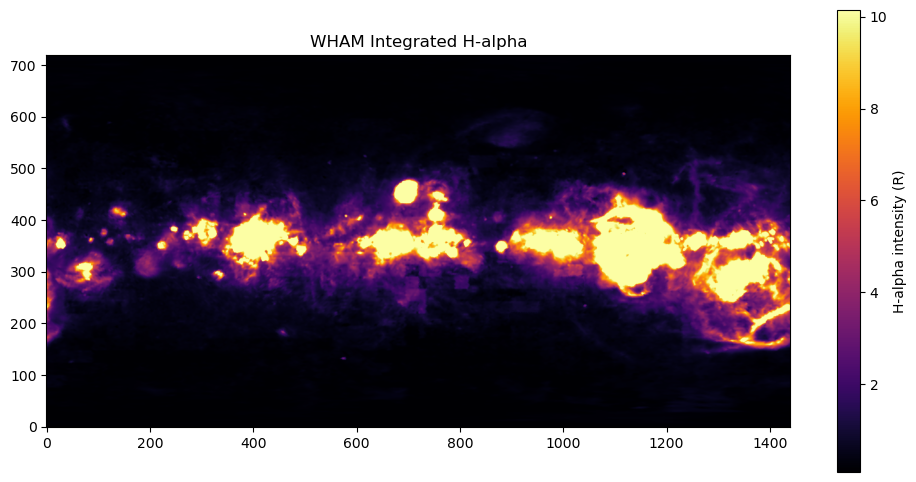

In [43]:
vmin = np.nanpercentile(whamIntegrated, 5)
vmax = np.nanpercentile(whamIntegrated, 95)

plt.figure(figsize=(12, 6))
plt.imshow(whamIntegrated, origin='lower', vmin=vmin, vmax=vmax, cmap='inferno')
plt.colorbar(label='H-alpha intensity (R)')
plt.title('WHAM Integrated H-alpha')
plt.show()

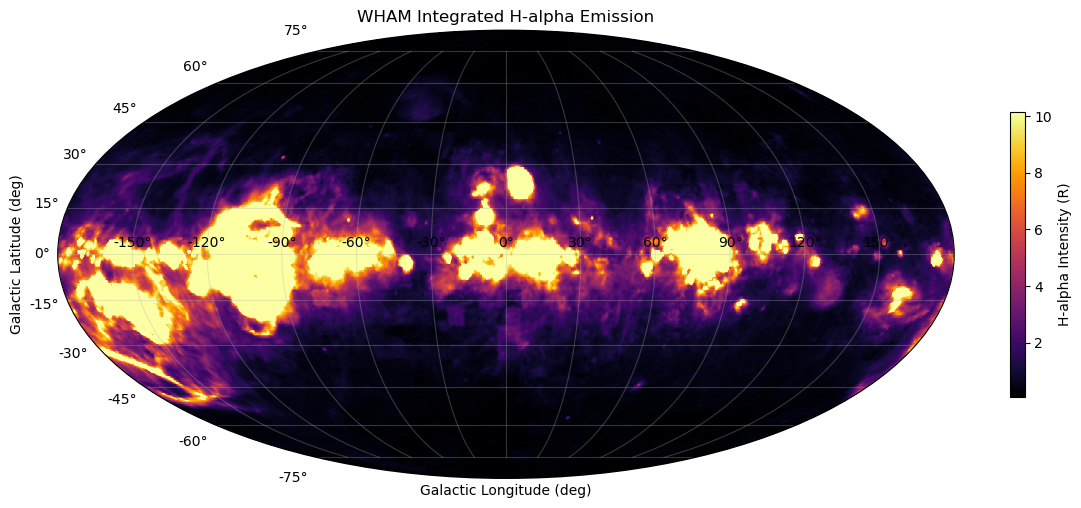

In [44]:
lon = np.linspace(180, -180, whamIntegrated.shape[1])
lat = np.linspace(-90, 90, whamIntegrated.shape[0])
lonGrid, latGrid = np.meshgrid(np.deg2rad(lon), np.deg2rad(lat))

vmin = np.nanpercentile(whamIntegrated, 5)
vmax = np.nanpercentile(whamIntegrated, 95)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='mollweide')
img = ax.pcolormesh(lonGrid, latGrid, whamIntegrated, cmap='inferno', vmin=vmin, vmax=vmax)
plt.colorbar(img, ax=ax, label='H-alpha Intensity (R)', shrink=0.5)
ax.set_xlabel('Galactic Longitude (deg)')
ax.set_ylabel('Galactic Latitude (deg)')
ax.grid(True, alpha=0.3)
plt.title('WHAM Integrated H-alpha Emission')
plt.tight_layout()
plt.show()

In [ ]:
whamhdr

In [45]:
# this cell groups pixels by faraday complexity
# collects their pixel coordinates and converts the pixel coordinates into 
# galactic coordinates so they can be matched to the wham data, at which point
# the intensity of the matched pixel is extracted. The data collected is
# stored in a dictionary for memory efficient easy access.

#declare wcs engines
wcsEngineFaraday = WCS(Npeakscarhdr)
wcsWham = WCS(whamhdr)

#grouping pixels by faraday complexity
uniqueComplexities, groupInverseIndices = np.unique(Npeakscardat, return_inverse=True)

#beginning of the loop
analysisLibraryHalpha = {}

for groupIndex, complexityValue in enumerate(uniqueComplexities):
    
    #Isolate matching pixels for the current group
    currentGroupMask = (groupInverseIndices == groupIndex)
    faradayPixelCoords = np.where(currentGroupMask)
    
    if len(faradayPixelCoords) == 0:
        continue
        
    #Extract the raw data values and flat pixel index tracks for this group
    currentFaradayValues = Npeakscardat[currentGroupMask]
    currentFlatPixels = np.flatnonzero(currentGroupMask)
    
   #Generate Galactic Coordinates (l, b) 
    worldCoordinates = wcsEngineFaraday.pixel_to_world(*faradayPixelCoords[::-1])
    skyPositions = SkyCoord(worldCoordinates)
    galacticCoordinates = skyPositions.galactic
    
    #Pack the spatial positions into a clean 2D Galactic SkyCoord object
    spatialPositions2D = SkyCoord(
        l=galacticCoordinates.l, 
        b=galacticCoordinates.b, 
        frame='galactic'
    )
    
    #Step B: Extract 2D Spatial Pixels Safely
    xFloats, yFloats = skycoord_to_pixel(spatialPositions2D, wcsWham, origin=0)
    
    xIndices = np.round(xFloats).astype(int)
    yIndices = np.round(yFloats).astype(int)
    
    #Boundary Guard Against 2D Array Layout (Y, X)
    #Query boundaries directly from wham
    yBoundSize = whamIntegrated.shape[0]
    xBoundSize = whamIntegrated.shape[1]
    
    inBounds = (
        (xIndices >= 0) & (xIndices < xBoundSize) &
        (yIndices >= 0) & (yIndices < yBoundSize)
    )
    
    #If no pixels in this group land inside the WHAM coverage window, skip to next group
    if not np.any(inBounds):
        continue
        
    #Data Extraction and Tuple Array Slicing
    validX = xIndices[inBounds]
    validY = yIndices[inBounds]
    
    #Define clean verified tracking tuple 
    validWhamIndices = (validY, validX)
    
    #Extract clean integrated intensity metrics from wham
    matchedWhamIntensities = whamIntegrated[validWhamIndices]
    
    #Save Final Subsets to Master Library
    analysisLibraryHalpha[complexityValue] = {
        "faradayValues": currentFaradayValues,
        "hAlphaIntensities": matchedWhamIntensities,
        "galacticLongitude": galacticCoordinates.l.degree,
        "galacticLatitude": galacticCoordinates.b.degree,
        "flatPixelNumbers": currentFlatPixels
    }

print(f"Pipeline executed successfully! Populated {len(analysisLibraryHalpha)} groups into 'analysisLibraryHalpha'.")


Pipeline executed successfully! Populated 9 groups into 'analysisLibraryHalpha'.


 [astropy.io.fits.verify]


In [46]:
uniqueComplexities

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8., nan], dtype='>f8')

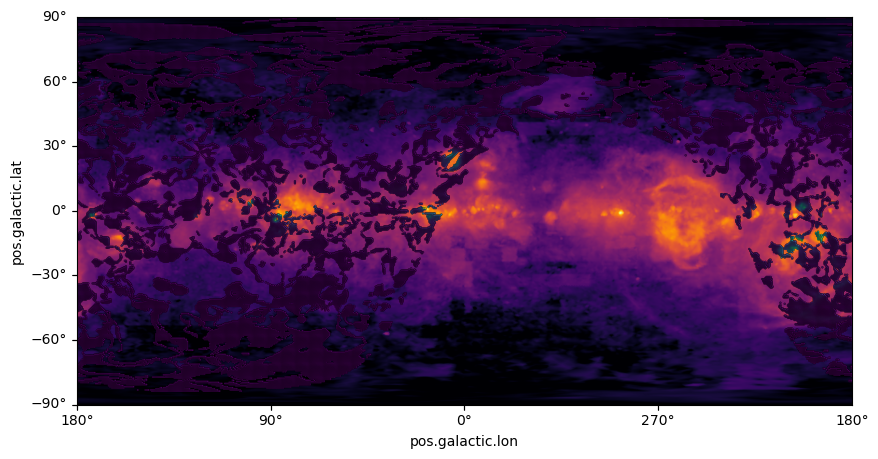

In [47]:
#want to verify the mapping worked going to make a plot 
wcsPlotEngine = WCS(whamhdr) 

if wcsPlotEngine.naxis > 2: 
    wcsPlotEngine = wcsPlotEngine.celestial 

targetTestGroup = 2

if targetTestGroup in analysisLibraryHalpha:
    groupData = analysisLibraryHalpha[targetTestGroup]

    testLongitudes = groupData["galacticLongitude"]
    testLatitudes = groupData["galacticLatitude"]
    testIntensities = groupData["hAlphaIntensities"]

    testPositionsSky = SkyCoord(l = testLongitudes, b = testLatitudes, frame = 'galactic', unit = 'deg') 

    plt.figure(figsize=(10,6)) 
    ax = plt.subplot(projection=wcsPlotEngine) 

    im = ax.imshow(np.log10(np.clip(whamIntegrated, 0.1, None)), cmap = 'inferno', origin = 'lower')

    scatterPlot = ax.scatter(
        testPositionsSky.l.degree, 
        testPositionsSky.b.degree,
        transform=ax.get_transform('galactic'),
        c=testIntensities, 
        cmap='viridis',
        s=2,
        edgecolor='black',
        linewidth=0.2,
        label=f'Extracted Peak {int(targetTestGroup)} Pixels'
    )

In [ ]:
#don't ever need to run the above cell again, just load the dictionary from here 
loadedArchive = np.load("faraday_halpha_analysis_results.npz")

analysisLibraryHalpha = {} 

for flatKey in loadedArchive.files: 
    keyParts = flatKey.split('_')

    complexityKey = float(keyParts[1]) if keyParts[1] != 'nan' else np.nan
    metricName = keyParts[2] 

    if complexityKey not in analysisLibraryHalpha: 
        analysisLibraryHalpha[complexityKey] = {} 

    analysisLibraryHalpha[complexityKey][metricName] = loadedArchive[flatKey]

print(f"Reloaded {len(analysisLibraryHalpha)} complexity groups into 'analysisLibraryHalpha'.")

In [110]:
from scipy.stats import pearsonr, spearmanr
import numpy as np
#original correlation cell 
allFaradayValues = np.concatenate([
    groupData["faradayValues"] for complexityKey, groupData in analysisLibraryHalpha.items() 
    if len(groupData["faradayValues"]) > 0 and not np.isnan(complexityKey)
])

# FIX: Swapped .values() to .items() so complexityKey can be read and evaluated safely
allHAlphaIntensities = np.concatenate([
    groupData["hAlphaIntensities"] for complexityKey, groupData in analysisLibraryHalpha.items() 
    if len(groupData["faradayValues"]) > 0 and not np.isnan(complexityKey)
])

print("--- Cleaned Population Diagnostics ---")
print(f"Total Combined Pixels (No NaNs): {len(allFaradayValues)}")
print(f"Faraday Value Range:             {np.min(allFaradayValues)} to {np.max(allFaradayValues)}")
print(f"Faraday Standard Deviation:       {np.std(allFaradayValues):.4f}")
print(f"H-Alpha Intensity Range:         {np.min(allHAlphaIntensities):.4f} to {np.max(allHAlphaIntensities):.4f}")

if len(allFaradayValues) >= 2 and np.std(allFaradayValues) > 0:
    pearsonCoefficient, pearsonPValue = pearsonr(allFaradayValues, allHAlphaIntensities)
    spearmanCoefficient, spearmanPValue = spearmanr(allFaradayValues, allHAlphaIntensities)

    print("\n--- Cleaned Global Correlation Results ---")
    print(f"Global Linear (Pearson r):       {pearsonCoefficient:.4f} (p: {pearsonPValue:.4e})")
    print(f"Global Monotonic (Spearman rho): {spearmanCoefficient:.4f} (p: {spearmanPValue:.4e})")
else:
    print("\nERROR: Cannot calculate correlation. Verify your arrays contain varying numbers.")


--- Cleaned Population Diagnostics ---
Total Combined Pixels (No NaNs): 169306
Faraday Value Range:             1.0 to 8.0
Faraday Standard Deviation:       1.1087
H-Alpha Intensity Range:         -0.7129 to 364.0431

--- Cleaned Global Correlation Results ---
Global Linear (Pearson r):       0.0116 (p: 1.9660e-06)
Global Monotonic (Spearman rho): 0.0623 (p: 2.8282e-145)


In [102]:
allFaradayValues[0:169287]

array([1., 1., 1., ..., 7., 7., 7.], shape=(169287,))

In [113]:
from scipy.stats import pearsonr, spearmanr, kendalltau
import numpy as np
#correlation cell attempting to account for latitude 

sortedKeys = sorted([k for k in analysisLibraryHalpha.keys() if not np.isnan(k)])
allFaraday = np.concatenate([analysisLibraryHalpha[k]["faradayValues"] for k in sortedKeys])

allHAlpha = np.concatenate([analysisLibraryHalpha[k]["hAlphaIntensities"] for k in sortedKeys])

allLatitudesRad = np.radians(np.concatenate([analysisLibraryHalpha[k]["galacticLatitude"] for k in sortedKeys]))

allHAlphaCorrected = allHAlpha * np.abs(np.sin(allLatitudesRad))
print("--- Population Diagnostics ---")
print(f"Total Combined Pixels (No NaNs): {len(allFaradayValues)}")
print(f"Complexity Range:             {np.min(allFaradayValues)} to {np.max(allFaradayValues)}")
print(f"Standard Deviation:       {np.std(allFaradayValues):.4f}")
print(f"H-Alpha Intensity Range:         {np.min(allHAlphaIntensities):.4f} to {np.max(allHAlphaIntensities):.4f}")
print(f"Median complexity:    {np.median(allFaradayValues):.4f}")

if len(allFaradayValues) >= 2 and np.std(allFaradayValues) > 0:
    pearsonCoefficient, pearsonPValue = pearsonr(allFaradayValues, allHAlphaCorrected)
    spearmanCoefficient, spearmanPValue = spearmanr(allFaradayValues, allHAlphaCorrected)

    print("\n--- Cleaned Global Correlation Results ---")
    print(f"Global Linear (Pearson r):       {pearsonCoefficient:.4f} (p: {pearsonPValue:.4e})")
    print(f"Global Monotonic (Spearman rho): {spearmanCoefficient:.4f} (p: {spearmanPValue:.4e})")
else:
    print("\nERROR: Cannot calculate correlation. Verify arrays contain varying numbers.")


--- Population Diagnostics ---
Total Combined Pixels (No NaNs): 169306
Complexity Range:             1.0 to 8.0
Standard Deviation:       1.1087
H-Alpha Intensity Range:         -0.7129 to 364.0431
Median complexity:    2.0000

--- Cleaned Global Correlation Results ---
Global Linear (Pearson r):       0.0019 (p: 4.4135e-01)
Global Monotonic (Spearman rho): 0.0756 (p: 5.3642e-213)


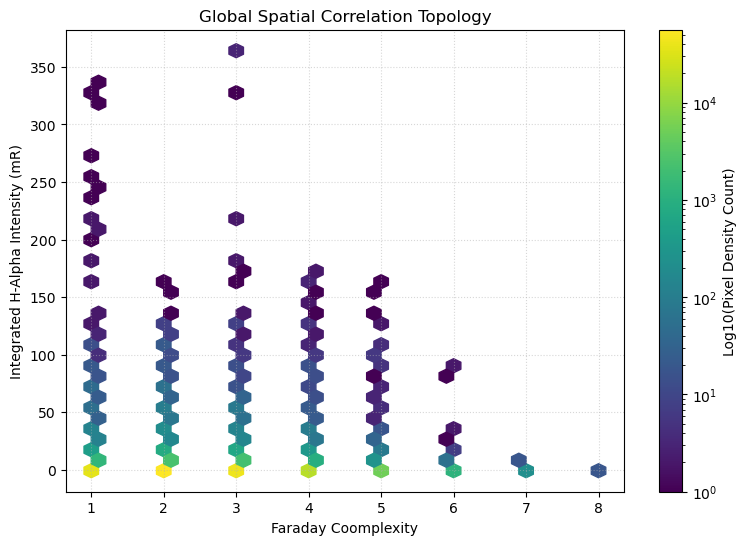

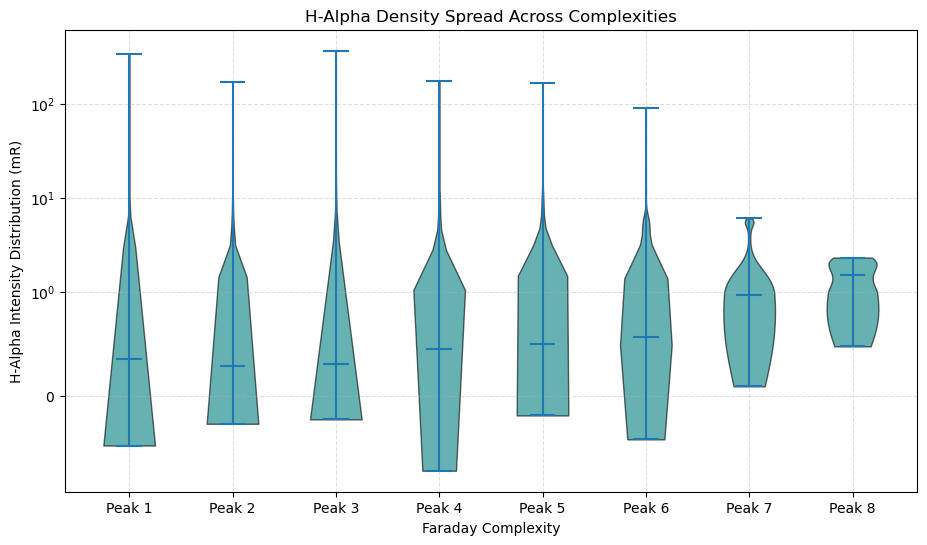

In [114]:
sortedComplexityKeys = sorted([k for k in analysisLibraryHalpha.keys() if not np.isnan(k)])

allFaradayClean = np.concatenate([analysisLibraryHalpha[k]["faradayValues"] for k in sortedComplexityKeys])
allHAlphaClean = np.concatenate([analysisLibraryHalpha[k]["hAlphaIntensities"] for k in sortedComplexityKeys])
hAlphaDistributions = [analysisLibraryHalpha[k]["hAlphaIntensities"] for k in sortedComplexityKeys]

plt.figure(figsize=(9,6)) 

hexPlot = plt.hexbin(
    allFaradayClean,
    allHAlphaClean, 
    gridsize=35, 
    cmap='viridis', 
     mincnt=1,
#The standard error shrinks to nearly zero.
# The test becomes hypersensitive to trivial movements.
# Virtually any non-zero correlation will return a significant
# -value.
    bins='log'
)

colorbar = plt.colorbar(hexPlot, label='Log10(Pixel Density Count)')
plt.xlabel('Faraday Coomplexity')
plt.ylabel('Integrated H-Alpha Intensity (mR)')
plt.title('Global Spatial Correlation Topology')
plt.grid(True, linestyle=':', alpha=0.5) 
plt.show()


plt.figure(figsize = (11, 6))

violinPlotParts = plt.violinplot(
    hAlphaDistributions, 
    showmeans=False, 
    showmedians=True, 
    showextrema=True
)

for body in violinPlotParts['bodies']: 
    body.set_facecolor('teal')
    body.set_edgecolor('black')
    body.set_alpha(0.6)
plt.yscale('symlog', linthresh=1.0)
plt.xticks(
    range(1, len(sortedComplexityKeys) + 1), 
    [f"Peak {int(k)}" for k in sortedComplexityKeys]
)
plt.xlabel('Faraday Complexity') 
plt.ylabel('H-Alpha Intensity Distribution (mR)') 
plt.title('H-Alpha Density Spread Across Complexities')
plt.grid(True, linestyle='--', alpha = 0.4) 
plt.show()

In [117]:
#partial correlation controlling for latitude 
import pandas as pd 
import pingouin as pg
allLatitudes = np.concatenate([analysisLibraryHalpha[k]["galacticLatitude"] for k in sortedComplexityKeys])
df = pd.DataFrame({
    'FaradayComplexity': allFaraday,
    'HAlpha': allHAlpha, 
    'AbsoluteLatitude': np.abs(allLatitudes) 
})

#compute partial spearman correlation 
partialResult = pg.partial_corr(
    data = df, 
    x = 'FaradayComplexity', 
    y = 'HAlpha', 
    covar = 'AbsoluteLatitude', 
    method = 'spearman'
)
print("PARTIAL SPEARMAN CORRELATION MATRIX RESULTS") 
print(r"Controlled Variable: Absolute Galactic Latitude") 
print(f"Partial rho:         {partialResult['r'].values[0]:.4f}")
print(f"P-Value:             {partialResult['p_val'].values[0]:.4e}")
print(f"95% Conf. Interval:  {partialResult['CI95'].values[0]}")

PARTIAL SPEARMAN CORRELATION MATRIX RESULTS
Controlled Variable: Absolute Galactic Latitude
Partial rho:         0.0562
P-Value:             1.8964e-118
95% Conf. Interval:  [0.05 0.06]


In [118]:
#doing a kendaltau test?

tau, p_value = kendalltau(allFaradayValues, allHAlphaIntensities)
tau, p_value

(np.float64(0.04674459593871714), np.float64(8.226446689721479e-147))

In [119]:
from sklearn.feature_selection import mutual_info_classif 
x = allHAlphaIntensities.reshape(-1,1)
score = mutual_info_classif(x, allFaradayValues)
score[0]

np.float64(0.01702819061082339)

In [120]:
#Mutual information 
from sklearn.feature_selection import mutual_info_regression 

x = allFaradayValues.reshape(-1,1) 
y = allHAlphaIntensities

score = mutual_info_regression(x, y, n_neighbors=3, random_state=42)
print(f"Mutual Information Score: {score[0]}")

Mutual Information Score: 0.017487377261266257


In [121]:
#distance correlation (need to do some batching, this is just a sample) 
from scipy.spatial.distance import pdist, squareform 

def distanceCorrelation(x, y, sampleSize = 100):
    idx = np.random.choice(len(x), size = sampleSize, replace=False)
    xs, ys = x[idx], y[idx]

    a = squareform(pdist(xs.reshape(-1,1)))
    b = squareform(pdist(ys.reshape(-1,1)))
    
    A = a - a.mean(axis=0)[None,:] - a.mean(axis=1)[:,None] + a.mean()
    B = b - b.mean(axis=0)[None,:] - b.mean(axis=1)[:,None] + b.mean()

    dcov = np.sqrt(np.mean(A*B))
    dvarX = np.sqrt(np.mean(A*A))
    dvarY = np.sqrt(np.mean(B*B))

    return dcov / np.sqrt(dvarX * dvarY)

x = allFaradayValues
y = allHAlphaIntensities

dcorScore = distanceCorrelation(x, y, sampleSize = 100)
dcorScore

np.float64(0.21375754048738477)

In [122]:
totalCleanPixels = len(allFaradayClean) 

print("=" * 65) 
print(f"{'Group':<8} | {'Pixel Count':<12} | {'Abundance %':<12} | {'Mean H-α':<10} | {'Median H-α':<10}")
print("=" * 65)

for complexityKey in sortedComplexityKeys: 
    groupFaraday = analysisLibraryHalpha[complexityKey]["faradayValues"]
    groupHAlpha = analysisLibraryHalpha[complexityKey]["hAlphaIntensities"]

    groupCount = len(groupFaraday)
    fractionalAbundance = (groupCount / totalCleanPixels) * 100 

    groupMean = np.mean(groupHAlpha) 
    groupMedian = np.median(groupHAlpha) 

    print(f"Peak {int(complexityKey):<3} | {groupCount:<12,} | {fractionalAbundance:<11.2f}% | {groupMean:<10.2f} | {groupMedian:<10.2f}")

print("=" * 65)

Group    | Pixel Count  | Abundance %  | Mean H-α   | Median H-α
Peak 1   | 37,695       | 22.26      % | 1.88       | 0.35      
Peak 2   | 60,185       | 35.55      % | 1.73       | 0.29      
Peak 3   | 45,373       | 26.80      % | 1.85       | 0.31      
Peak 4   | 18,940       | 11.19      % | 2.18       | 0.45      
Peak 5   | 5,602        | 3.31       % | 2.22       | 0.50      
Peak 6   | 1,250        | 0.74       % | 1.64       | 0.57      
Peak 7   | 242          | 0.14       % | 1.54       | 0.97      
Peak 8   | 19           | 0.01       % | 1.42       | 1.51      


In [123]:
cleaned_library = {
    ('nan' if isinstance(k, (float, np.float64)) and np.isnan(k) else k): v 
    for k, v in analysisLibraryHalpha.items()
}
print(cleaned_library['nan'])

{'faradayValues': array([nan, nan, nan, ..., nan, nan, nan], shape=(89894,), dtype='>f8'), 'hAlphaIntensities': array([0.08947901, 0.0894445 , 0.08940983, ..., 0.14057188, 0.13987844,
       0.10842731], shape=(89894,), dtype=float32), 'galacticLongitude': array([179.75, 179.25, 178.75, ..., 276.25, 275.75,  27.25],
      shape=(89894,)), 'galacticLatitude': array([-89.75, -89.75, -89.75, ...,  81.75,  81.75,  85.25],
      shape=(89894,)), 'flatPixelNumbers': array([     0,      1,      2, ..., 247487, 247488, 252305],
      shape=(89894,))}


In [124]:
print(analysisLibraryHalpha.keys())
totalPix = 89894 + len(analysisLibraryHalpha[1.0]['hAlphaIntensities'])+len(analysisLibraryHalpha[2.0]['hAlphaIntensities'])+len(analysisLibraryHalpha[3.0]['hAlphaIntensities'])+len(analysisLibraryHalpha[4.0]['hAlphaIntensities'])+len(analysisLibraryHalpha[5.0]['hAlphaIntensities'])+len(analysisLibraryHalpha[6.0]['hAlphaIntensities'])+len(analysisLibraryHalpha[7.0]['hAlphaIntensities'])+len(analysisLibraryHalpha[8.0]['hAlphaIntensities'])#+len(analysisLibraryHalpha[0.0]['hAlphaIntensities'])
totalPixFits = np.count_nonzero(Npeakscardat)
complexPix =len(analysisLibraryHalpha[2.0]['hAlphaIntensities'])+len(analysisLibraryHalpha[3.0]['hAlphaIntensities'])+len(analysisLibraryHalpha[4.0]['hAlphaIntensities'])+len(analysisLibraryHalpha[5.0]['hAlphaIntensities'])+len(analysisLibraryHalpha[6.0]['hAlphaIntensities'])+len(analysisLibraryHalpha[7.0]['hAlphaIntensities'])+len(analysisLibraryHalpha[8.0]['hAlphaIntensities'])
pctComplex = (complexPix / totalPix) * 100 
print("Percent of northern sky displaying complexity: ", pctComplex, "%")
complexPix, totalPix, totalPixFits

dict_keys([np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(nan)])
Percent of northern sky displaying complexity:  50.775848765432094 %


(131611, 259200, 259200)

In [125]:
from scipy.stats import kruskal 

import scikit_posthocs as sp 

stat, pGlobal = kruskal(*hAlphaDistributions) 
print(f"Kruskal-Wallis Global P-Value: {pGlobal:.50e}")

dunnMatrix = sp.posthoc_dunn(hAlphaDistributions, p_adjust=None)
print("\np=values between sequential peaks:") 
for i in range(len(sortedComplexityKeys)-1):
    pPair = dunnMatrix.iloc[i, i+1]
    print(f"Peak {int(sortedComplexityKeys[i])} vs Peak {int(sortedComplexityKeys[i+1])}: p = {pPair:.4e}")

Kruskal-Wallis Global P-Value: 0.00000000000000000000000000000000000000000000000000e+00

p=values between sequential peaks:
Peak 1 vs Peak 2: p = 1.2013e-35
Peak 2 vs Peak 3: p = 2.8123e-34
Peak 3 vs Peak 4: p = 1.2153e-118
Peak 4 vs Peak 5: p = 1.8116e-04
Peak 5 vs Peak 6: p = 4.4321e-07
Peak 6 vs Peak 7: p = 7.8853e-05
Peak 7 vs Peak 8: p = 3.0958e-01


In [126]:
#going to run a T-test 
from scipy.stats import ttest_ind 

sortedComplexityKeys = sorted([k for k in analysisLibraryHalpha.keys() if not np.isnan(k)])

print("WELCH'S T-TEST BETWEEN SEQUENTIAL COMPLEXITY PEAKS") 

for i in range(len(sortedComplexityKeys) -1): 
    currentKey = sortedComplexityKeys[i]
    nextKey = sortedComplexityKeys[i+1] 

    currentHalpha = analysisLibraryHalpha[currentKey]["hAlphaIntensities"]
    nextHalpha = analysisLibraryHalpha[nextKey]["hAlphaIntensities"]

    tStat, pValue = ttest_ind(currentHalpha, nextHalpha, equal_var=False, nan_policy='omit')

    print(f"Peak {int(currentKey)} vs Peak {int(nextKey)}:")
    print(f"  t-statistic: {tStat:10.4f} | p-value: {pValue:.4e}")


WELCH'S T-TEST BETWEEN SEQUENTIAL COMPLEXITY PEAKS
Peak 1 vs Peak 2:
  t-statistic:     2.9843 | p-value: 2.8430e-03
Peak 2 vs Peak 3:
  t-statistic:    -2.8401 | p-value: 4.5112e-03
Peak 3 vs Peak 4:
  t-statistic:    -5.0861 | p-value: 3.6742e-07
Peak 4 vs Peak 5:
  t-statistic:    -0.3034 | p-value: 7.6161e-01
Peak 5 vs Peak 6:
  t-statistic:     3.3311 | p-value: 8.7507e-04
Peak 6 vs Peak 7:
  t-statistic:     0.5584 | p-value: 5.7665e-01
Peak 7 vs Peak 8:
  t-statistic:     0.6986 | p-value: 4.8892e-01


--- Model Fitting Comparison (^2 Scores) --- 
Linear Fit:      R² = 0.0000 -> Equation: y = 0.15*x + -0.04
Exponential Fit: R² = 0.0000 -> Equation: y = 0.12 * e^(0.31*x)
Power-Law Fit:   R² = 0.0000 -> Equation: y = 0.03 * x^1.78


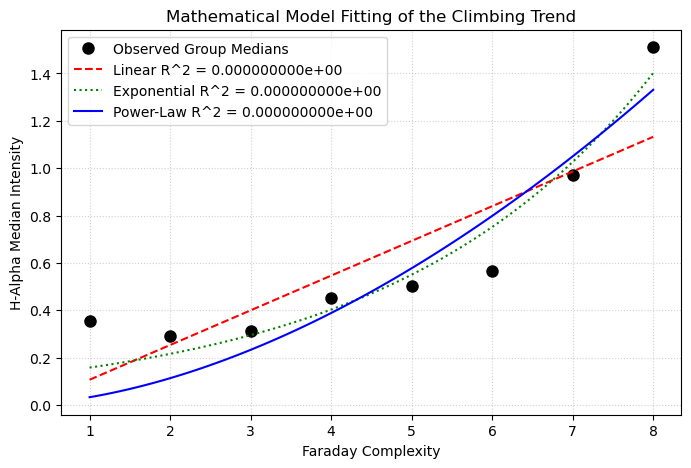

In [127]:
from scipy.optimize import curve_fit 

xData = np.array([int(k) for k in sortedComplexityKeys])
yMedians = np.array([np.median(dist) for dist in hAlphaDistributions])

def linearModel(x, m, c):
    return m*x+c 

def exponentialModel(x, a, b):
    return a*np.exp(b*x)

def powerLawModel(x, a, k):
    return a * (x**k)

poptLin, _ = curve_fit(linearModel,xData,yMedians)
poptExp, _ = curve_fit(exponentialModel, xData, yMedians, p0=[1.0, 0.1])
poptPow, _ = curve_fit(powerLawModel, xData, yMedians, p0=[1.0, 1.0])

def calculateRSquared(yObserved, yFitted): 
    residualSumSquares = np.sum((yObserved - np.mean(yObserved)) **2)
    totalSumSquares = np.sum((yObserved - np.mean(yObserved))**2)
    return 1 - (residualSumSquares / totalSumSquares)

r2Linear = calculateRSquared(yMedians, linearModel(xData, *poptLin))
r2Exponential = calculateRSquared(yMedians, exponentialModel(xData, *poptExp))
r2PowerLaw = calculateRSquared(yMedians, powerLawModel(xData, *poptPow))

print("--- Model Fitting Comparison (^2 Scores) --- ") 
print(f"Linear Fit:      R² = {r2Linear:.4f} -> Equation: y = {poptLin[0]:.2f}*x + {poptLin[1]:.2f}")
print(f"Exponential Fit: R² = {r2Exponential:.4f} -> Equation: y = {poptExp[0]:.2f} * e^({poptExp[1]:.2f}*x)")
print(f"Power-Law Fit:   R² = {r2PowerLaw:.4f} -> Equation: y = {poptPow[0]:.2f} * x^{poptPow[1]:.2f}")

plt.figure(figsize = (8, 5))
plt.plot(xData, yMedians, 'ko', markersize = 8, label = 'Observed Group Medians')
xFine = np.linspace(min(xData), max(xData), 100)
plt.plot(xFine, linearModel(xFine, *poptLin), 'r--', label=f'Linear R^2 = {r2Linear:.9e}')
plt.plot(xFine, exponentialModel(xFine, *poptExp), 'g:', label=f'Exponential R^2 = {r2Exponential:.9e}')
plt.plot(xFine, powerLawModel(xFine, *poptPow), 'b-', label=f'Power-Law R^2 = {r2PowerLaw:.9e}')

plt.xlabel('Faraday Complexity')
plt.ylabel('H-Alpha Median Intensity')
plt.title('Mathematical Model Fitting of the Climbing Trend')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha = 0.6)

--- Model Fitting Comparison (R^2 Scores) --- 
Linear Fit:      R² = 0.5407 -> Equation: y = 0.04*x + 0.24
Exponential Fit: R² = 0.7226 -> Equation: y = 0.24 * e^(0.12*x)
Power-Law Fit:   R² = 0.1542 -> Equation: y = 0.28 * x^0.21
Spearman correlation $\rho$: {np.float64(0.07559240229260158)}


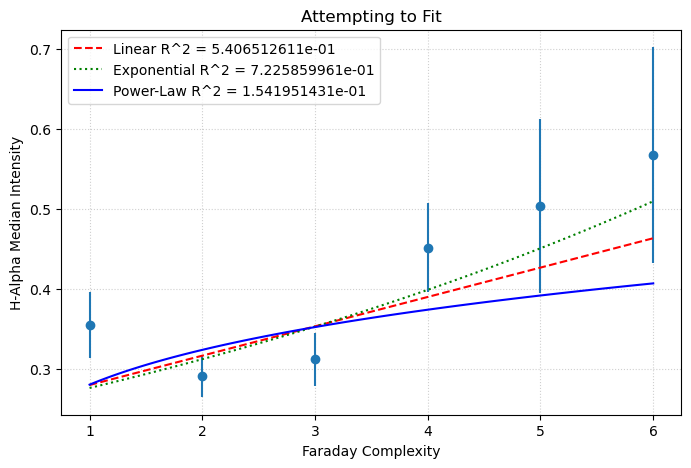

In [155]:
#fitting with weights  

xData = np.array([int(k) for k in sortedComplexityKeys[0:6:1]])
yMedians = np.array([np.median(dist) for dist in hAlphaDistributions[0:6:1]])
yErr = (np.array([np.std(dist)/np.sqrt(len(dist)) for dist in hAlphaDistributions[0:6:1]]))

def linearModel(x, m, c):
    return m*x+c 

def exponentialModel(x, a, b):
    return a*np.exp(b*x)

def powerLawModel(x, a, k):
    return a * (x**k)

poptLin, pLincov = curve_fit(linearModel,xData,yMedians, sigma = (yErr))
poptExp, pExpcov = curve_fit(exponentialModel, xData, yMedians, p0=[1.0, 0.1], sigma = (yErr))
poptPow, pPowcov = curve_fit(powerLawModel, xData, yMedians, p0=[1.0, 1.0], sigma = (yErr))

def calculateRSquared(yObserved, yFitted): 
    residualSumSquares = np.sum((yObserved - np.mean(yObserved)) **2)
    totalSumSquares = np.sum((yObserved - np.mean(yObserved))**2)
    return 1 - (residualSumSquares / totalSumSquares)
def calculateRSquared(yObserved, yFitted):
    residualSumSquares = np.sum((yObserved-yFitted)**2)
    totalSumSquares = np.sum((yObserved-np.mean(yObserved))**2)
    return 1 - (residualSumSquares / totalSumSquares)
r2Linear = calculateRSquared(yMedians, linearModel(xData, *poptLin))
r2Exponential = calculateRSquared(yMedians, exponentialModel(xData, *poptExp))
r2PowerLaw = calculateRSquared(yMedians, powerLawModel(xData, *poptPow))

print("--- Model Fitting Comparison (R^2 Scores) --- ") 
print(f"Linear Fit:      R² = {r2Linear:.4f} -> Equation: y = {poptLin[0]:.2f}*x + {poptLin[1]:.2f}")
print(f"Exponential Fit: R² = {r2Exponential:.4f} -> Equation: y = {poptExp[0]:.2f} * e^({poptExp[1]:.2f}*x)")
print(f"Power-Law Fit:   R² = {r2PowerLaw:.4f} -> Equation: y = {poptPow[0]:.2f} * x^{poptPow[1]:.2f}")
print(r"Spearman correlation $\rho$:", {spearmanCoefficient})
plt.figure(figsize = (8, 5))
plt.errorbar(xData, yMedians, yerr = yErr, fmt = 'o')#, label = 'Observed Group Medians')
xFine = np.linspace(min(xData), max(xData), 100)
plt.plot(xFine, linearModel(xFine, *poptLin), 'r--', label=f'Linear R^2 = {r2Linear:.9e}')
plt.plot(xFine, exponentialModel(xFine, *poptExp), 'g:', label=f'Exponential R^2 = {r2Exponential:.9e}')
plt.plot(xFine, powerLawModel(xFine, *poptPow), 'b-', label=f'Power-Law R^2 = {r2PowerLaw:.9e}')

plt.xlabel('Faraday Complexity')
plt.ylabel('H-Alpha Median Intensity')
plt.title('Attempting to Fit')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha = 0.6)

In [90]:
hAlphaDistributions

[array([-0.02253135, -0.03167786, -0.03301297, ...,  0.15103   ,
         0.15126008,  0.15148358], shape=(37695,), dtype=float32),
 array([0.11178599, 0.11367594, 0.11546988, ..., 0.14992827, 0.14982873,
        0.14973567], shape=(60185,), dtype=float32),
 array([0.11290224, 0.10909002, 0.10711494, ..., 0.14942373, 0.14935978,
        0.149301  ], shape=(45373,), dtype=float32),
 array([0.13523227, 0.1383151 , 0.1421399 , ..., 0.11881293, 0.11803953,
        0.11709012], shape=(18940,), dtype=float32),
 array([0.26474187, 0.20699984, 0.4996616 , ..., 0.07084032, 0.07173305,
        0.0728837 ], shape=(5602,), dtype=float32),
 array([0.18612497, 0.20609993, 0.22740203, ..., 0.11652028, 0.1220965 ,
        0.12881579], shape=(1250,), dtype=float32),
 array([0.19764316, 0.20693596, 0.21140149, 2.833448  , 2.409016  ,
        2.3456037 , 2.351937  , 1.2240359 , 1.3159456 , 1.5678152 ,
        1.3497354 , 1.4962703 , 5.2536464 , 5.4768634 , 5.469815  ,
        5.675     , 5.531048  , 5.38

--- Log-Space Model Fitting Comparison (R² Scores) ---
Linear Fit (Exponential Growth): R² = 0.8455 -> Slope (m): 0.0935
Power-Law Fit (Scaling Index):   R² = 0.6100 -> Exponent (k): 0.6366


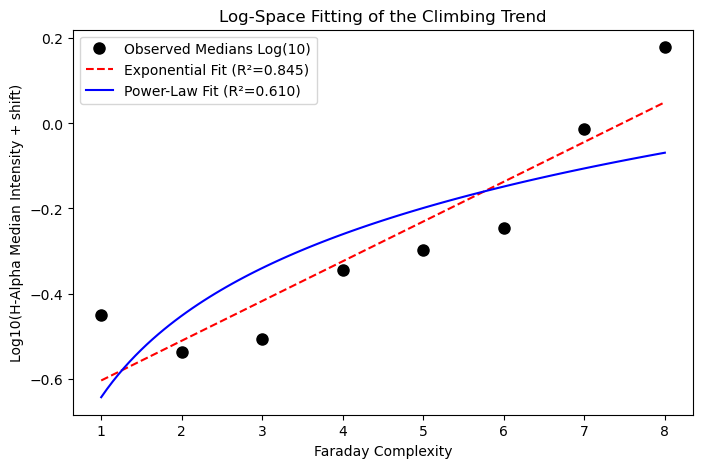

In [66]:
#going to try fitting in log space now 
yFloorShift = 0.0 
if np.min(yMedians) <= 0:
    yFloorShift = abs(np.min(yMedians)) + 1.0 

yMediansLog = np.log10(yMedians + yFloorShift)

def linearLogModel(x, m, c): 
    return m * x + c 
def powerLawLogModel(x, logA, k):
    return logA + k * np.log10(x)

poptLinLog, _ = curve_fit(linearLogModel, xData, yMediansLog)
poptPowLog, _ = curve_fit(powerLawLogModel, xData, yMediansLog, p0=[1.0, 1.0])

def calculateRSquared(yObserved, yFitted):
    residualSumSquares = np.sum((yObserved - yFitted) ** 2)
    totalSumSquares = np.sum((yObserved - np.mean(yObserved)) ** 2)
    return 1 - (residualSumSquares / totalSumSquares)

r2LinearLog = calculateRSquared(yMediansLog, linearLogModel(xData, *poptLinLog))
r2PowerLawLog = calculateRSquared(yMediansLog, powerLawLogModel(xData, *poptPowLog))

print("--- Log-Space Model Fitting Comparison (R² Scores) ---")
print(f"Linear Fit (Exponential Growth): R² = {r2LinearLog:.4f} -> Slope (m): {poptLinLog[0]:.4f}")
print(f"Power-Law Fit (Scaling Index):   R² = {r2PowerLawLog:.4f} -> Exponent (k): {poptPowLog[1]:.4f}")

plt.figure(figsize = (8,5))
plt.plot(xData, yMediansLog, 'ko', markersize = 8, label = 'Observed Medians Log(10)')
xFine = np.linspace(min(xData), max(xData), 100)
plt.plot(xFine, linearLogModel(xFine, *poptLinLog), 'r--', label=f'Exponential Fit (R²={r2LinearLog:.3f})')
plt.plot(xFine, powerLawLogModel(xFine, *poptPowLog), 'b-', label=f'Power-Law Fit (R²={r2PowerLawLog:.3f})')

plt.xlabel('Faraday Complexity') 
plt.ylabel('Log10(H-Alpha Median Intensity + shift)')
plt.title('Log-Space Fitting of the Climbing Trend')
plt.legend(loc='upper left')
plt.show()

In [67]:
#printing the equations 
slopeM = poptLinLog[0]
interceptC = poptLinLog[1]

exponentialAmplitude = 10**interceptC


logAmplitudeA = poptPowLog[0]
scalingIndexK = poptPowLog[1]

powerLawAmplitude = 10**logAmplitudeA 


print("FINAL PHYSICAL EQUATIONS (Linear Space)")
print("=" * 65)
print("1. EXPONENTIAL GROWTH MODEL (R² = 0.788):")
print(f"   H-Alpha = ({exponentialAmplitude:.4f} * 10^({slopeM:.4f} * Peaks)) - {yFloorShift:.2f}")
print("2. POWER-LAW MODEL (R² = 0.573):")
print(f"   H-Alpha = ({powerLawAmplitude:.4f} * Peaks^{scalingIndexK:.4f}) - {yFloorShift:.2f}")
print(f"\n Turbulent scaling index of k = {scalingIndexK:.4f}.*")
print("=" * 65)

FINAL PHYSICAL EQUATIONS (Linear Space)
1. EXPONENTIAL GROWTH MODEL (R² = 0.788):
   H-Alpha = (0.2005 * 10^(0.0935 * Peaks)) - 0.00
2. POWER-LAW MODEL (R² = 0.573):
   H-Alpha = (0.2271 * Peaks^0.6366) - 0.00

 Turbulent scaling index of k = 0.6366.*


In [ ]:
#saving the analysislibrary to disk 
flattenedHalphaDict = {}

for complexityKey, dataArrays, in analysisLibraryHalpha.items(): 
    keyString = f"{complexityKey:.4f}" if not np.isnan(complexityKey) else "nan"

    for metricName, numpyArray in dataArrays.items(): 
        flattenedHalphaDict[f"group_{keyString}_{metricName}"] = numpyArray

outputFileName = "faraday_halpha_analysis_results.npz"

np.savez_compressed(outputFileName, **flattenedHalphaDict)
print(f"Saved compressed dataset to: {outputFileName}")objects in the sky above 100 mRayleighs

# not totally sure of the importance of the below plots

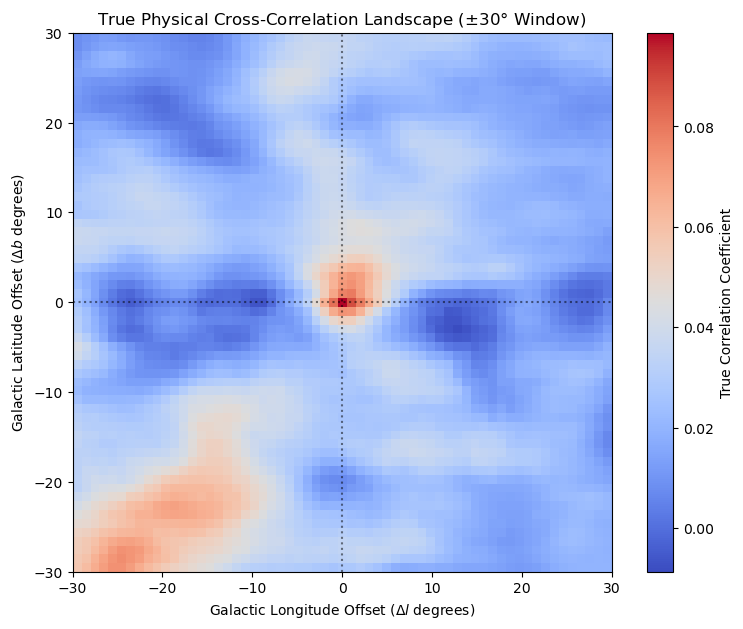

True Physical Peak found at offset: Delta l = 0° , Delta b = 0° with value: 0.0987


In [68]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import shift

# Gather clean master keys from your library
# CORRECTED FIX: Use .keys() so k is just the numeric complexity value
sortedKeys = sorted([k for k in analysisLibraryHalpha.keys() if not np.isnan(k)])

# Determine the matrix canvas size based on your real coordinate boundaries
maxIndexY = max(np.max(group["galacticLatitude"]) for group in analysisLibraryHalpha.values() if len(group["galacticLatitude"]) > 0)
maxIndexX = max(np.max(group["galacticLongitude"]) for group in analysisLibraryHalpha.values() if len(group["galacticLongitude"]) > 0)

# Build a zero-padded grid patch based on your real coordinate bounds
gridShapeY = int(np.ceil(maxIndexY)) + 1
gridShapeX = int(np.ceil(maxIndexX)) + 1

faradayGrid = np.zeros((gridShapeY, gridShapeX))
hAlphaGrid = np.zeros((gridShapeY, gridShapeX))

# Map your clean vector datasets into the 2D spatial cross-correlation workspace
for complexityKey in sortedKeys:
    groupData = analysisLibraryHalpha[complexityKey]
    # Round degrees to generic integer grid steps for cross-correlation mapping
    yGridIndices = np.round(groupData["galacticLatitude"]).astype(int)
    xGridIndices = np.round(groupData["galacticLongitude"]).astype(int)
    
    faradayGrid[yGridIndices, xGridIndices] = groupData["faradayValues"]
    hAlphaGrid[yGridIndices, xGridIndices] = groupData["hAlphaIntensities"]

# Standardize the data fields to compute true correlation tracking indices
faradayGridNorm = (faradayGrid - np.mean(faradayGrid)) / np.std(faradayGrid)
hAlphaGridNorm = (hAlphaGrid - np.mean(hAlphaGrid)) / np.std(hAlphaGrid)

#  PHYSICAL SHIFT ENGINE (NON-PERIODIC)
#  shift the maps manually to prevent Pac-Man wrap-around
maxOffset = 30 
offsetRange = range(-maxOffset, maxOffset + 1)

spatialCCFPhysical = np.zeros((len(offsetRange), len(offsetRange)))

for i, dy in enumerate(offsetRange):
    for j, dx in enumerate(offsetRange):
        # Shift the Faraday grid. cval=0.0 means empty spaces are padded with zeros, NOT wrapped!
        shiftedFaraday = shift(faradayGridNorm, shift=[dy, dx], cval=0.0)
        # Compute the direct overlap correlation coefficient
        spatialCCFPhysical[i, j] = np.sum(hAlphaGridNorm * shiftedFaraday) / faradayGridNorm.size

# VISUALIZE TRUE LANDSCAPE
plt.figure(figsize=(9, 7))
plt.imshow(
    spatialCCFPhysical, 
    cmap='coolwarm', 
    origin='lower', 
    extent=[-maxOffset, maxOffset, -maxOffset, maxOffset]
)

plt.colorbar(label='True Correlation Coefficient')
plt.xlabel('Galactic Longitude Offset ($\Delta l$ degrees)')
plt.ylabel('Galactic Latitude Offset ($\Delta b$ degrees)')
plt.title(f'True Physical Cross-Correlation Landscape ($\pm${maxOffset}° Window)')
plt.axhline(0, color='black', linestyle=':', alpha=0.5)
plt.axvline(0, color='black', linestyle=':', alpha=0.5)
plt.show()

# Extract true global peak metrics
peakY, peakX = np.unravel_index(np.argmax(spatialCCFPhysical), spatialCCFPhysical.shape)
offsetX = offsetRange[peakX]
offsetY = offsetRange[peakY]
print(f"True Physical Peak found at offset: Delta l = {offsetX}° , Delta b = {offsetY}° with value: {np.max(spatialCCFPhysical):.4f}")


In [69]:
sortedKeys = sorted([k for k in analysisLibraryHalpha.keys() if not np.isnan(k)])

maxIndexY = max(np.max(group["galacticLatitude"]) for group in analysisLibraryHalpha.values() if len(group["galacticLatitude"]) > 0)
maxIndexX = max(np.max(group["galacticLongitude"]) for group in analysisLibraryHalpha.values() if len(group["galacticLongitude"]) > 0)

gridShapeY = int(np.ceil(maxIndexY)) + 1 
gridShapeX = int(np.ceil(maxIndexX)) + 1 

faradayGrid = np.zeros((gridShapeY, gridShapeX))
hAlphaGrid = np.zeros((gridShapeY, gridShapeX))

for complexityKey in sortedKeys: 
    groupData = analysisLibraryHalpha[complexityKey]
    yGridIndices = np.round(groupData["galacticLatitude"]).astype(int)
    xGridIndices = np.round(groupData["galacticLongitude"]).astype(int)

    faradayGrid[yGridIndices, xGridIndices] = groupData["faradayValues"]
    hAlphaGrid[yGridIndices, xGridIndices] = groupData["hAlphaIntensities"]

#standardizing grids
faradayGridNorm = (faradayGrid - np.mean(faradayGrid)) / np.std(faradayGrid)
hAlphaGridNorm = (hAlphaGrid - np.mean(hAlphaGrid))/np.std(hAlphaGrid) 

#do ffts 
fftFaraday = np.fft.fft2(faradayGridNorm)
fftHalpha = np.fft.fft2(hAlphaGridNorm)

#power spectra components
#variance per frequency ( auto-power) 
powerFarday = np.abs(fftFaraday) ** 2
powerHAlpha = np.abs(fftHAlpha) ** 2

#cross power spectrum 
crossPower = fftHAlpha * np.conj(fftFaraday)
#frequency shifting
powerFaradayShifted = np.fft.fftshift(powerFaraday) 
powerHAlphaShifted = np.fft.fftshift(powerHAlpha) 
crossPowerShifted = np.fft.fftshift(crossPower) 
#generating spatial frequency grid 
ySize, xSize = faradayGridNorm.shape 
yFreqs = np.fft.fftshift(np.fft.fftfreq(ySize, d = 1.0))
xFreqs = np.fft.fftshift(np.fft.fftfreq(xSize, d = 1.0))

xMesh, yMesh = np.meshgrid(xFreqs, yFreqs) 
radialSpatialFrequencies = np.sqrt(xMesh**2 + yMesh**2) 

#binning 
maxFreq = np.max(radialSpatialFrequencies)
frequencyBins = np.linspace(0.01, maxFreq, 40) 
binCenters = 0.5 * (frequencyBins[:-1] + frequencyBins[1:])

binnedPxx = np.zeros(len(binCenters))
binnedPyy = np.zeros(len(binCenters))
binnedPxy = np.zeros(len(binCenters), dtype=complex)

for i in range(len(frequencyBins) - 1): 
        binMask = (radialSpatialFrequencies >= frequencyBins[i]) * (radialSpatialFrequencies < frequencyBins[i+1])
        if np.any(binMask):
            binnedPxx[i] = np.mean(powerFaradayShifted[binMask])
            binnedPyy[i] = np.mean(powerHAlphaShifted[binMask])
            binnedPxy[i] = np.mean(crossPowerShifted[binMask])

#squared coherence spectrum 
coherenceSpectrum = (np.abs(binnedPxy) ** 2) / (binnedPxx * binnedPyy)

#spatial frequencies into angulamaxIndexY = max(np.max(group["galacticLatitude"]) for group in analysisLibraryHalpha.values() if len(group["galacticLatitude"]) > 0)r size scales
angularScalesDegrees = 1.0 / binCenters 

plt.figure(figsize=(8,5))
plt.plot(angularScalesDegrees, coherenceSpectrum, 's-', color='darkblue', linewidth=2, markersize=5)

plt.xscale('linear')
plt.xlabel('Angular Spatial Scale (Degrees on Sky)')
plt.ylabel(r'Magnitude Squared Coherence ($\gamma^2$)')
plt.title('Bivariate Coherence Spectrum: Scale-Dependent Correlation')

# plt.gca().invert_xaxis()


NameError: name 'fftHAlpha' is not defined